<a href="https://colab.research.google.com/github/subratjain101/deepfakedetector/blob/main/deepfakedetector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Preparing to capture images. Please click 'Capture' for each image that appears.
Capturing image 1/1...


<IPython.core.display.Javascript object>

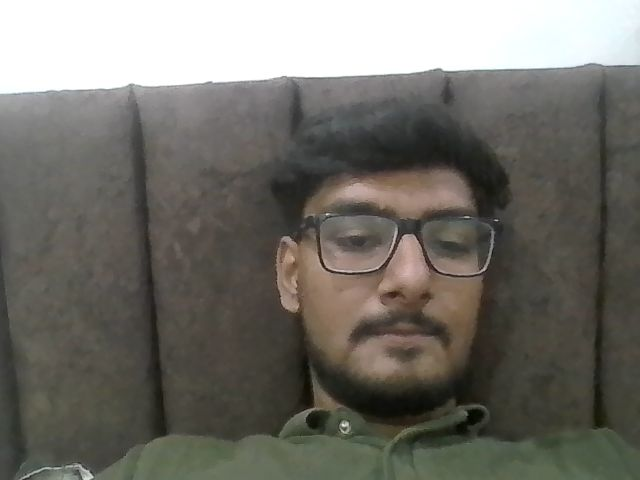

Image capture process finished.


In [1]:
import cv2
import os
import uuid
import time
from google.colab import patches
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

# Function to capture photo using Javascript for Colab environment
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for button to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

IMAGES_PATH = os.path.join("data", "images")
os.makedirs(IMAGES_PATH, exist_ok=True)

number_images = 1

print("Preparing to capture images. Please click 'Capture' for each image that appears.")

for imgnum in range(number_images):
    print(f"Capturing image {imgnum + 1}/{number_images}...")
    try:
        # Capture image using the take_photo helper function
        imgname = os.path.join(
            IMAGES_PATH,
            f"{uuid.uuid1()}.jpg"
        )
        captured_filename = take_photo(filename=imgname)

        # Read the captured image with cv2 to display it
        frame = cv2.imread(captured_filename)

        # Use Colab's specific imshow patch to display the captured frame
        patches.cv2_imshow(frame)

    except Exception as e:
        print(f"Failed to capture image: {e}. Make sure you grant camera access when prompted and click 'Capture' for each image.")
        break

    time.sleep(0.5) # Wait a bit before capturing the next image

print("Image capture process finished.")


Detected 1 faces.


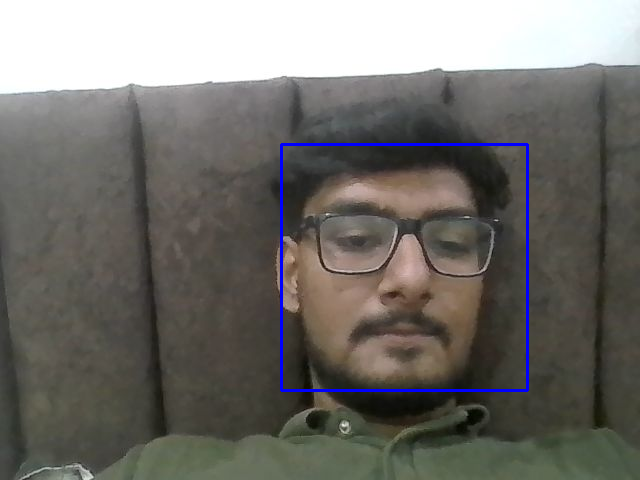

In [2]:
!pip install --upgrade opencv-contrib-python

import cv2
from google.colab.patches import cv2_imshow
import os
import urllib.request

# Path to the cascade file
cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"

# Fallback: Download the XML file if it's not found in cv2.data.haarcascades
if not os.path.exists(cascade_path):
    url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
    cascade_path = "haarcascade_frontalface_default.xml"
    if not os.path.exists(cascade_path):
        urllib.request.urlretrieve(url, cascade_path)

try:
    face_detector = cv2.CascadeClassifier(cascade_path)

    if face_detector.empty():
        raise IOError("Could not load the face cascade classifier.")

    # Use the filename from the previous capture cell
    if 'captured_filename' not in globals():
        import glob
        list_of_files = glob.glob('data/images/*.jpg')
        image_path = max(list_of_files, key=os.path.getctime) if list_of_files else ""
    else:
        image_path = captured_filename

    if image_path and os.path.exists(image_path):
        image = cv2.imread(image_path)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        faces = face_detector.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(80, 80)
        )

        for (x, y, w, h) in faces:
            cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)

        print(f"Detected {len(faces)} faces.")
        cv2_imshow(image)
    else:
        print("No image found. Please run the first cell to capture a photo.")

except (AttributeError, IOError) as e:
    print(f"Error: {e}")
    print("If you just installed the package, please click 'Runtime' -> 'Restart runtime' and run this cell again.")

Cropped Face:


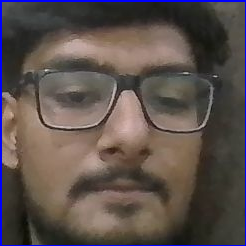

In [4]:
from google.colab.patches import cv2_imshow

for (x, y, w, h) in faces:
    # Crop the face from the original image
    face = image[y:y+h, x:x+w]

    # Use Colab's patch instead of cv2.imshow
    print("Cropped Face:")
    cv2_imshow(face)

Resized Face:


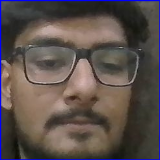

In [8]:
from google.colab.patches import cv2_imshow

# Resize the face image to 160x160 pixels
face = cv2.resize(face, (160, 160))

# Use Colab's patch to display the image instead of cv2.imshow
print("Resized Face:")
cv2_imshow(face)

In [9]:
!pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.5 MB/s eta 0:00:00


In [12]:
from deepface import DeepFace

# We set detector_backend='skip' because the image we are passing
# is already cropped to the face or we have already verified detection.
# This avoids the ValueError related to missing OpenCV XML files in DeepFace.
embedding = DeepFace.represent(
    img_path=image_path,
    model_name="Facenet",
    enforce_detection=False,
    detector_backend="skip"
)

vector = embedding[0]["embedding"]

print("Embedding size:", len(vector))
print("First 10 values of the vector:", vector[:10])

Embedding size: 128
First 10 values of the vector: [-0.2633489668369293, -0.2989690899848938, -0.41606876254081726, -0.8139223456382751, 0.2703453302383423, 0.24385052919387817, -0.255649209022522, 0.19575119018554688, 0.1344606578350067, -0.01499178260564804]


In [19]:
from deepface import DeepFace
import os

# Your actual captured image path from the previous cells
img1_path_verify = image_path

# Placeholder for a second image - you need to capture or upload this!
# For now, we compare the captured image against itself as a test
img2_path_verify = image_path

if os.path.exists(img1_path_verify) and os.path.exists(img2_path_verify):
    result = DeepFace.verify(
        img1_path=img1_path_verify,
        img2_path=img2_path_verify,
        model_name="Facenet",
        enforce_detection=False, # Set to False to prevent detection errors if a face isn't perfectly detected
        detector_backend="skip" # Skip detection if embeddings are already known or image is pre-processed
    )
    print(result)
else:
    print("Error: One or both image paths do not exist. Please ensure 'image_path' is correctly defined.")

{'verified': True, 'distance': -0.0, 'threshold': 0.4, 'confidence': 100.0, 'model': 'Facenet', 'detector_backend': 'skip', 'similarity_metric': 'cosine', 'facial_areas': {'img1': {'x': 0, 'y': 0, 'w': 639, 'h': 479, 'left_eye': None, 'right_eye': None}, 'img2': {'x': 0, 'y': 0, 'w': 639, 'h': 479, 'left_eye': None, 'right_eye': None}}, 'time': 0.48}


In [14]:
from deepface import DeepFace
import os

# Your actual captured image path from the previous cells
img1 = image_path

# Placeholder for a second image - you need to capture or upload this!
# For now, we compare the captured image against itself as a test
img2 = image_path

if os.path.exists(img1) and os.path.exists(img2):
    result = DeepFace.verify(
        img1_path=img1,
        img2_path=img2,
        model_name="Facenet",
        enforce_detection=False,
        detector_backend="skip"
    )
    print(result)
else:
    print("Error: One or both image paths do not exist.")

{'verified': True, 'distance': -0.0, 'threshold': 0.4, 'confidence': 100.0, 'model': 'Facenet', 'detector_backend': 'skip', 'similarity_metric': 'cosine', 'facial_areas': {'img1': {'x': 0, 'y': 0, 'w': 639, 'h': 479, 'left_eye': None, 'right_eye': None}, 'img2': {'x': 0, 'y': 0, 'w': 639, 'h': 479, 'left_eye': None, 'right_eye': None}}, 'time': 0.45}


In [15]:
import numpy as np

def cosine_similarity(a, b):

    a = np.array(a)
    b = np.array(b)

    similarity = np.dot(a, b) / (
        np.linalg.norm(a) * np.linalg.norm(b)
    )

    return similarity

In [17]:
embedding1 = DeepFace.represent(
    img_path=image_path,
    model_name="Facenet",
    enforce_detection=False,
    detector_backend="skip"
)[0]["embedding"]

# IMPORTANT: For meaningful comparison, you need a *second* distinct image.
# For now, we are using the same image path for demonstration purposes.
# You will need to capture or upload a second image and update 'img2_path_for_embedding'
# with its path to get a different embedding.
img2_path_for_embedding = image_path # Placeholder, replace with path to actual second image

embedding2 = DeepFace.represent(
    img_path=img2_path_for_embedding,
    model_name="Facenet",
    enforce_detection=False,
    detector_backend="skip"
)[0]["embedding"]

similarity = cosine_similarity(
    embedding1,
    embedding2
)

print("Cosine Similarity:", similarity)

Cosine Similarity: 1.0


In [18]:
threshold = 0.7

if similarity >= threshold:
    print("Same person")
else:
    print("Different person")

Same person
